In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1500

data = {
    "Order_ID": range(10001, 10001 + n),
    "Order_Date": pd.date_range(start="2025-01-01", periods=n, freq="D"),
    "City": np.random.choice(
        ["Delhi", "Mumbai", "Bangalore", "Hyderabad", "Pune", "Chennai"],
        n
    ),
    "Category": np.random.choice(
        ["Electronics", "Clothing", "Grocery", "Beauty", "Home & Kitchen"],
        n
    ),
    "Distance_KM": np.round(np.random.uniform(1, 30, n), 2),
    "Traffic_Level": np.random.choice(
        ["Low", "Medium", "High"],
        n,
        p=[0.3, 0.45, 0.25]
    ),
    "Weather": np.random.choice(
        ["Clear", "Cloudy", "Rainy"],
        n,
        p=[0.5, 0.3, 0.2]
    ),
    "Delivery_Partner": np.random.choice(
        ["Partner A", "Partner B", "Partner C", "Partner D"],
        n
    ),
    "Order_Value": np.round(np.random.uniform(200, 5000, n), 2),
    "Preparation_Time": np.random.randint(5, 31, n)
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Dataset created successfully!
Number of rows: 1500
Number of columns: 10


In [3]:
# Calculate expected delivery time based on distance
df["Expected_Delivery_Time"] = (
    20
    + (df["Distance_KM"] * 2)
    + df["Preparation_Time"]
)

# Calculate actual delivery time
traffic_delay = df["Traffic_Level"].map({
    "Low": 0,
    "Medium": 10,
    "High": 20
})

weather_delay = df["Weather"].map({
    "Clear": 0,
    "Cloudy": 3,
    "Rainy": 12
})

random_delay = np.random.randint(-5, 11, n)

df["Actual_Delivery_Time"] = (
    df["Expected_Delivery_Time"]
    + traffic_delay
    + weather_delay
    + random_delay
)

# Make sure delivery time is never negative
df["Actual_Delivery_Time"] = df["Actual_Delivery_Time"].clip(lower=10)

# Create delivery status
df["Delivery_Status"] = np.where(
    df["Actual_Delivery_Time"] <= df["Expected_Delivery_Time"],
    "On Time",
    "Delayed"
)

print("Delivery intelligence columns created successfully!")

Delivery intelligence columns created successfully!


In [4]:
# Display the first 5 rows
df.head()

,Order_ID,Order_Date,City,Category,Distance_KM,Traffic_Level,Weather,Delivery_Partner,Order_Value,Preparation_Time,Expected_Delivery_Time,Actual_Delivery_Time,Delivery_Status
0,10001,2025-01-01,Hyderabad,Clothing,15.87,Medium,Rainy,Partner D,3395.77,15,66.74,89.74,Delayed
1,10002,2025-01-02,Pune,Beauty,9.85,High,Clear,Partner B,1573.88,16,55.70,78.70,Delayed
2,10003,2025-01-03,Bangalore,Grocery,7.17,Low,Rainy,Partner B,2408.49,17,51.34,63.34,Delayed
3,10004,2025-01-04,Pune,Home & Kitchen,1.96,High,Clear,Partner A,1128.55,8,31.92,61.92,Delayed
4,10005,2025-01-05,Pune,Beauty,9.81,Low,Rainy,Partner A,1209.79,11,50.62,72.62,Delayed


In [5]:
# Check the number of rows and columns
df.shape

(1500, 13)

In [6]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order_ID                1500 non-null   int64         
 1   Order_Date              1500 non-null   datetime64[ns]
 2   City                    1500 non-null   object        
 3   Category                1500 non-null   object        
 4   Distance_KM             1500 non-null   float64       
 5   Traffic_Level           1500 non-null   object        
 6   Weather                 1500 non-null   object        
 7   Delivery_Partner        1500 non-null   object        
 8   Order_Value             1500 non-null   float64       
 9   Preparation_Time        1500 non-null   int64         
 10  Expected_Delivery_Time  1500 non-null   float64       
 11  Actual_Delivery_Time    1500 non-null   float64       
 12  Delivery_Status         1500 non-null   object  

In [7]:
# Statistical summary of numerical columns
df.describe()

,Order_ID,Order_Date,Distance_KM,Order_Value,Preparation_Time,Expected_Delivery_Time,Actual_Delivery_Time
count,1500.000000,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,10750.500000,2027-01-20 12:00:00.000000256,15.369773,2515.359033,17.474667,68.214213,83.380880
min,10001.000000,2025-01-01 00:00:00,1.000000,201.170000,5.000000,27.000000,27.340000
25%,10375.750000,2026-01-10 18:00:00,8.275000,1324.470000,11.000000,53.435000,67.590000
50%,10750.500000,2027-01-20 12:00:00,15.315000,2467.925000,17.000000,68.090000,83.110000
75%,11125.250000,2028-01-30 06:00:00,22.552500,3630.590000,24.000000,82.705000,98.815000
max,11500.000000,2029-02-08 00:00:00,29.990000,4994.740000,30.000000,107.680000,142.900000
std,433.157015,NaN,8.357638,1363.788976,7.430534,18.505877,20.847335


In [8]:
# Check for missing values
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
City,0
Category,0
Distance_KM,0
Traffic_Level,0
Weather,0
Delivery_Partner,0
Order_Value,0
Preparation_Time,0


In [9]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [10]:
# Check data types of all columns
df.dtypes

,0
Order_ID,int64
Order_Date,datetime64[ns]
City,object
Category,object
Distance_KM,float64
Traffic_Level,object
Weather,object
Delivery_Partner,object
Order_Value,float64
Preparation_Time,int64


In [11]:
# Feature Engineering

# Calculate delivery delay in minutes
df["Delay_Minutes"] = (
    df["Actual_Delivery_Time"] - df["Expected_Delivery_Time"]
)

# Extract day of the week
df["Day_of_Week"] = df["Order_Date"].dt.day_name()

# Extract month
df["Month"] = df["Order_Date"].dt.month_name()

# Display the new columns
df[[
    "Order_ID",
    "Expected_Delivery_Time",
    "Actual_Delivery_Time",
    "Delay_Minutes",
    "Day_of_Week",
    "Month"
]].head()

,Order_ID,Expected_Delivery_Time,Actual_Delivery_Time,Delay_Minutes,Day_of_Week,Month
0,10001,66.74,89.74,23.0,Wednesday,January
1,10002,55.70,78.70,23.0,Thursday,January
2,10003,51.34,63.34,12.0,Friday,January
3,10004,31.92,61.92,30.0,Saturday,January
4,10005,50.62,72.62,22.0,Sunday,January


In [12]:
# Calculate average delivery times

avg_expected = df["Expected_Delivery_Time"].mean()
avg_actual = df["Actual_Delivery_Time"].mean()
avg_delay = df["Delay_Minutes"].mean()

print("Average Expected Delivery Time:", round(avg_expected, 2), "minutes")
print("Average Actual Delivery Time:", round(avg_actual, 2), "minutes")
print("Average Delay:", round(avg_delay, 2), "minutes")

Average Expected Delivery Time: 68.21 minutes
Average Actual Delivery Time: 83.38 minutes
Average Delay: 15.17 minutes


In [13]:
# Count delivery status

status_counts = df["Delivery_Status"].value_counts()

print(status_counts)

Delivery_Status
Delayed    1395
On Time     105
Name: count, dtype: int64


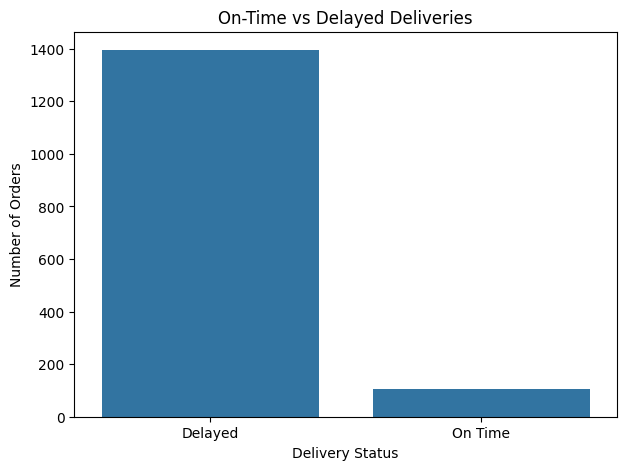

In [14]:
# Visualize delivery status

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Delivery_Status"
)

plt.title("On-Time vs Delayed Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.show()

In [15]:
# Average delivery time by traffic level

traffic_analysis = df.groupby("Traffic_Level")["Actual_Delivery_Time"].mean().sort_values()

print(traffic_analysis.round(2))

Traffic_Level
Low       74.25
Medium    84.30
High      93.10
Name: Actual_Delivery_Time, dtype: float64


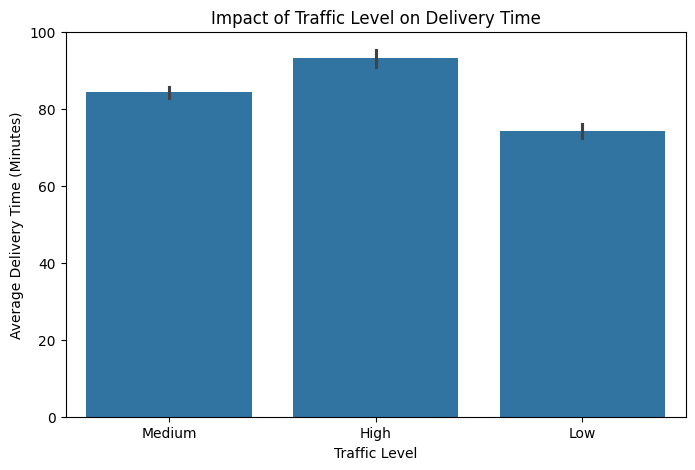

In [16]:
# Visualize traffic level vs delivery time

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Traffic_Level",
    y="Actual_Delivery_Time"
)

plt.title("Impact of Traffic Level on Delivery Time")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (Minutes)")

plt.show()

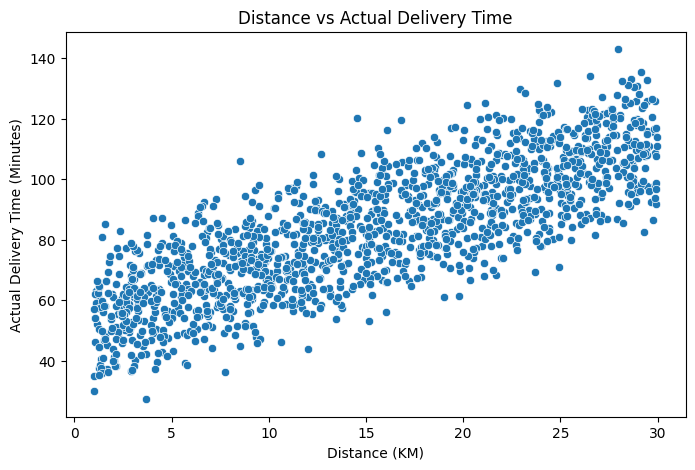

In [17]:
# Relationship between distance and actual delivery time

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Distance_KM",
    y="Actual_Delivery_Time"
)

plt.title("Distance vs Actual Delivery Time")
plt.xlabel("Distance (KM)")
plt.ylabel("Actual Delivery Time (Minutes)")

plt.show()

In [18]:
# Calculate average delivery time by city

city_analysis = (
    df.groupby("City")["Actual_Delivery_Time"]
    .mean()
    .sort_values(ascending=False)
)

print(city_analysis.round(2))

City
Chennai      85.48
Mumbai       84.28
Pune         83.92
Delhi        83.11
Bangalore    82.19
Hyderabad    81.30
Name: Actual_Delivery_Time, dtype: float64


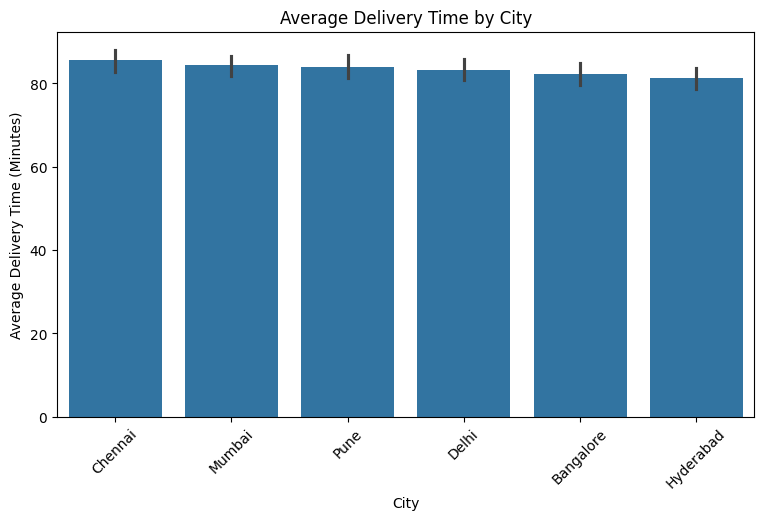

In [19]:
# Visualize city-wise delivery time

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="City",
    y="Actual_Delivery_Time",
    order=city_analysis.index
)

plt.title("Average Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Average Delivery Time (Minutes)")
plt.xticks(rotation=45)

plt.show()

In [20]:
# Calculate delay rate by city

delay_rate_city = (
    df.groupby("City")["Delivery_Status"]
    .apply(lambda x: (x == "Delayed").mean() * 100)
    .sort_values(ascending=False)
)

print("Delay Rate by City (%):")
print(delay_rate_city.round(2))

Delay Rate by City (%):
City
Mumbai       95.04
Pune         94.86
Chennai      93.15
Delhi        92.11
Hyderabad    91.53
Bangalore    91.36
Name: Delivery_Status, dtype: float64


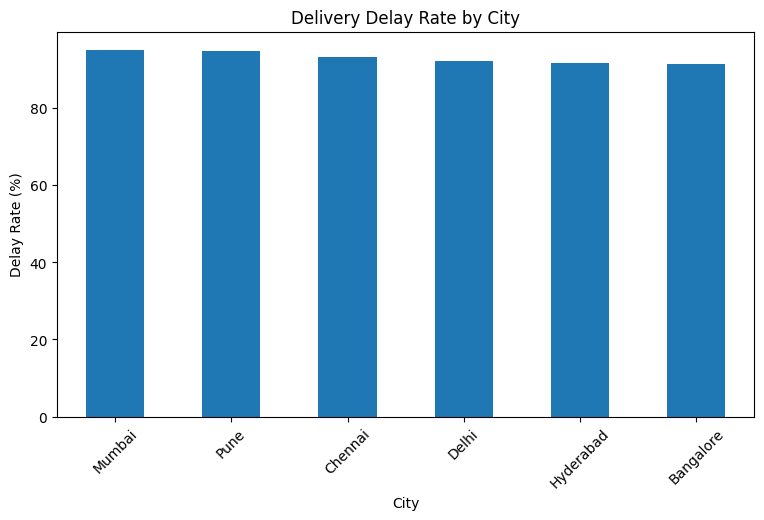

In [21]:
plt.figure(figsize=(9, 5))

delay_rate_city.plot(kind="bar")

plt.title("Delivery Delay Rate by City")
plt.xlabel("City")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [22]:
# Average delivery time by weather condition

weather_analysis = (
    df.groupby("Weather")["Actual_Delivery_Time"]
    .mean()
    .sort_values(ascending=False)
)

print(weather_analysis.round(2))

Weather
Rainy     91.84
Cloudy    81.73
Clear     80.96
Name: Actual_Delivery_Time, dtype: float64


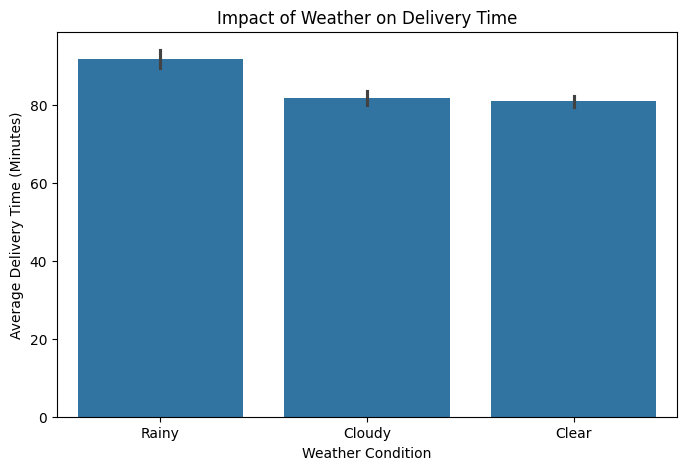

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Weather",
    y="Actual_Delivery_Time",
    order=weather_analysis.index
)

plt.title("Impact of Weather on Delivery Time")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (Minutes)")

plt.show()

In [24]:
# Average delivery time by delivery partner

partner_analysis = (
    df.groupby("Delivery_Partner")["Actual_Delivery_Time"]
    .mean()
    .sort_values()
)

print(partner_analysis.round(2))

Delivery_Partner
Partner C    81.98
Partner A    82.72
Partner D    83.66
Partner B    85.12
Name: Actual_Delivery_Time, dtype: float64


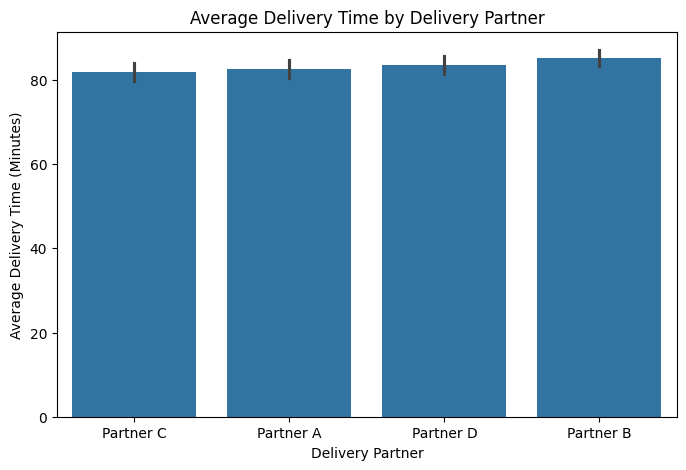

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Delivery_Partner",
    y="Actual_Delivery_Time",
    order=partner_analysis.index
)

plt.title("Average Delivery Time by Delivery Partner")
plt.xlabel("Delivery Partner")
plt.ylabel("Average Delivery Time (Minutes)")

plt.show()

In [26]:
# Calculate delay rate by delivery partner

partner_delay_rate = (
    df.groupby("Delivery_Partner")["Delivery_Status"]
    .apply(lambda x: (x == "Delayed").mean() * 100)
    .sort_values(ascending=False)
)

print("Delay Rate by Delivery Partner (%):")
print(partner_delay_rate.round(2))

Delay Rate by Delivery Partner (%):
Delivery_Partner
Partner B    94.01
Partner A    92.98
Partner D    92.70
Partner C    92.24
Name: Delivery_Status, dtype: float64


In [27]:
# Select numerical columns
numerical_columns = [
    "Distance_KM",
    "Order_Value",
    "Preparation_Time",
    "Expected_Delivery_Time",
    "Actual_Delivery_Time",
    "Delay_Minutes"
]

correlation_matrix = df[numerical_columns].corr()

print(correlation_matrix.round(2))

                        Distance_KM  Order_Value  Preparation_Time  \
Distance_KM                    1.00        -0.02              0.03   
Order_Value                   -0.02         1.00              0.05   
Preparation_Time               0.03         0.05              1.00   
Expected_Delivery_Time         0.92         0.00              0.43   
Actual_Delivery_Time           0.81         0.01              0.38   
Delay_Minutes                 -0.00         0.02             -0.01   

                        Expected_Delivery_Time  Actual_Delivery_Time  \
Distance_KM                               0.92                  0.81   
Order_Value                               0.00                  0.01   
Preparation_Time                          0.43                  0.38   
Expected_Delivery_Time                    1.00                  0.88   
Actual_Delivery_Time                      0.88                  1.00   
Delay_Minutes                            -0.01                  0.46   

    

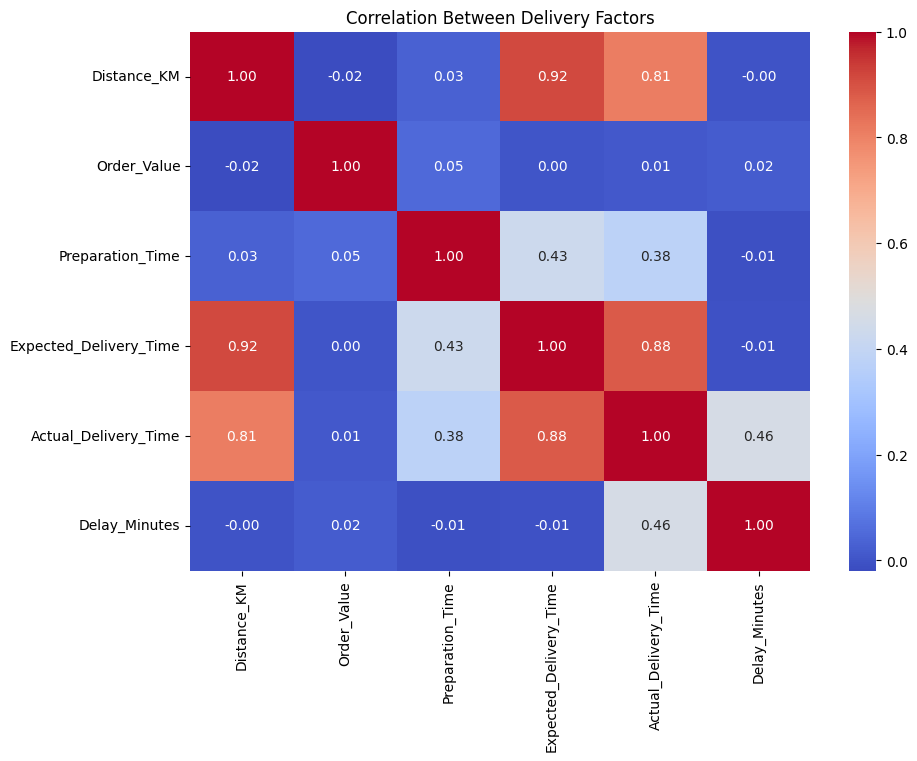

In [28]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Delivery Factors")

plt.show()

In [29]:
# Correlation with actual delivery time

actual_time_correlation = (
    correlation_matrix["Actual_Delivery_Time"]
    .sort_values(ascending=False)
)

print("Correlation with Actual Delivery Time:")
print(actual_time_correlation.round(2))

Correlation with Actual Delivery Time:
Actual_Delivery_Time      1.00
Expected_Delivery_Time    0.88
Distance_KM               0.81
Delay_Minutes             0.46
Preparation_Time          0.38
Order_Value               0.01
Name: Actual_Delivery_Time, dtype: float64


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Machine Learning libraries imported successfully!")

Machine Learning libraries imported successfully!


In [31]:
# Select features for the ML model

features = [
    "Distance_KM",
    "Traffic_Level",
    "Weather",
    "Preparation_Time",
    "Expected_Delivery_Time"
]

X = df[features]
y = df["Actual_Delivery_Time"]

# Convert categorical variables into numerical variables
X = pd.get_dummies(
    X,
    columns=["Traffic_Level", "Weather"],
    drop_first=True
)

print("Features prepared successfully!")
print("Number of input features:", X.shape[1])
print("Target variable:", y.name)

Features prepared successfully!
Number of input features: 7
Target variable: Actual_Delivery_Time


In [32]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1200, 7)
Testing data: (300, 7)


In [33]:
# Create the Random Forest model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [34]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[77.3168     79.1086     50.82173333 91.159      88.7646     67.6638
 72.8868     60.132      97.9724     80.0046    ]


In [35]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE :", round(mae, 2), "minutes")
print("RMSE:", round(rmse, 2), "minutes")
print("R²  :", round(r2, 2))

Model Performance
------------------
MAE : 4.18 minutes
RMSE: 4.97 minutes
R²  : 0.95


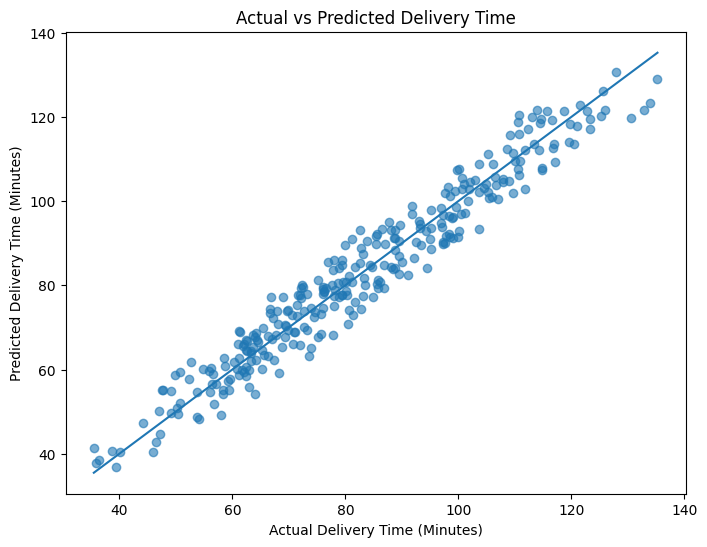

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Delivery Time (Minutes)")
plt.ylabel("Predicted Delivery Time (Minutes)")
plt.title("Actual vs Predicted Delivery Time")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [37]:
# Feature importance

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance.round(3))

Feature Importance:
Expected_Delivery_Time    0.820
Traffic_Level_Low         0.077
Weather_Rainy             0.040
Traffic_Level_Medium      0.030
Distance_KM               0.016
Preparation_Time          0.012
Weather_Cloudy            0.004
dtype: float64


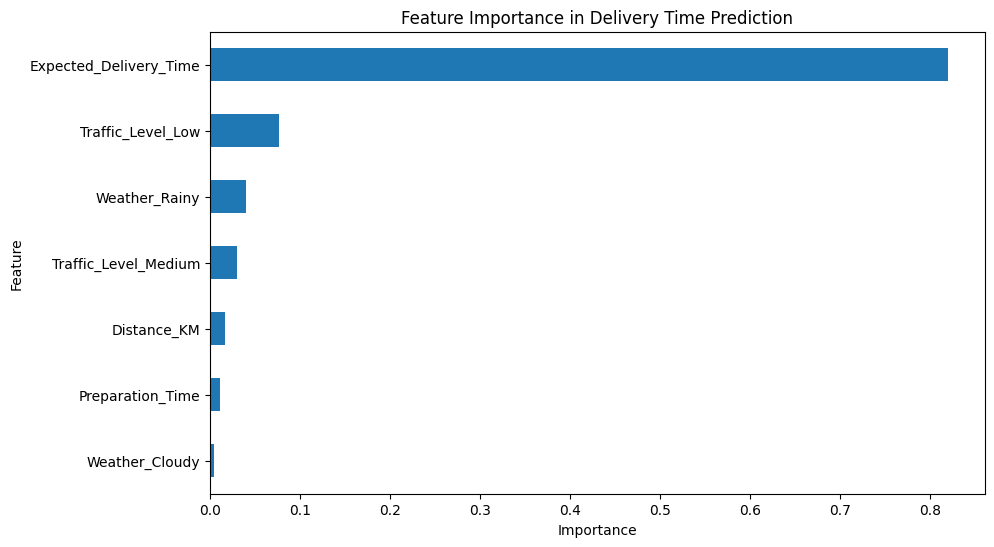

In [38]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance in Delivery Time Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [39]:
# Generate key business insights

highest_city = city_analysis.index[0]
highest_city_time = city_analysis.iloc[0]

lowest_city = city_analysis.index[-1]
lowest_city_time = city_analysis.iloc[-1]

highest_traffic = traffic_analysis.index[-1]
highest_traffic_time = traffic_analysis.iloc[-1]

worst_weather = weather_analysis.index[0]
worst_weather_time = weather_analysis.iloc[0]

best_partner = partner_analysis.index[0]
best_partner_time = partner_analysis.iloc[0]

print("KEY BUSINESS INSIGHTS")
print("=" * 50)

print(f"1. {highest_city} has the highest average delivery time "
      f"at {highest_city_time:.2f} minutes.")

print(f"2. {lowest_city} has the lowest average delivery time "
      f"at {lowest_city_time:.2f} minutes.")

print(f"3. {highest_traffic} traffic has the highest average delivery "
      f"time at {highest_traffic_time:.2f} minutes.")

print(f"4. {worst_weather} weather has the highest average delivery "
      f"time at {worst_weather_time:.2f} minutes.")

print(f"5. {best_partner} has the lowest average delivery time "
      f"among delivery partners at {best_partner_time:.2f} minutes.")

KEY BUSINESS INSIGHTS
1. Chennai has the highest average delivery time at 85.48 minutes.
2. Hyderabad has the lowest average delivery time at 81.30 minutes.
3. High traffic has the highest average delivery time at 93.10 minutes.
4. Rainy weather has the highest average delivery time at 91.84 minutes.
5. Partner C has the lowest average delivery time among delivery partners at 81.98 minutes.


In [40]:
# Business Recommendations

print("BUSINESS RECOMMENDATIONS")
print("=" * 50)

print("1. Focus on improving delivery operations in cities "
      "with higher average delivery times.")

print("2. Use real-time traffic information to improve delivery "
      "time estimates and route planning.")

print("3. During rainy weather, consider additional delivery "
      "time buffers to set realistic customer expectations.")

print("4. Compare delivery partner performance regularly and "
      "allocate more orders to consistently better-performing partners.")

print("5. Use the machine learning model to estimate delivery "
      "time before dispatch and proactively identify potential delays.")

BUSINESS RECOMMENDATIONS
1. Focus on improving delivery operations in cities with higher average delivery times.
2. Use real-time traffic information to improve delivery time estimates and route planning.
3. During rainy weather, consider additional delivery time buffers to set realistic customer expectations.
4. Compare delivery partner performance regularly and allocate more orders to consistently better-performing partners.
5. Use the machine learning model to estimate delivery time before dispatch and proactively identify potential delays.


In [41]:
print("DELIVERY TIME INTELLIGENCE PROJECT")
print("=" * 50)

print("Dataset Size:", df.shape)
print("Average Expected Delivery Time:",
      round(df["Expected_Delivery_Time"].mean(), 2), "minutes")
print("Average Actual Delivery Time:",
      round(df["Actual_Delivery_Time"].mean(), 2), "minutes")
print("Average Delay:",
      round(df["Delay_Minutes"].mean(), 2), "minutes")

delay_percentage = (
    (df["Delivery_Status"] == "Delayed").mean() * 100
)

print("Overall Delay Rate:",
      round(delay_percentage, 2), "%")

print("\nMachine Learning Performance")
print("----------------------------")
print("MAE:", round(mae, 2), "minutes")
print("RMSE:", round(rmse, 2), "minutes")
print("R² Score:", round(r2, 2))

print("\nProject completed successfully!")

DELIVERY TIME INTELLIGENCE PROJECT
Dataset Size: (1500, 16)
Average Expected Delivery Time: 68.21 minutes
Average Actual Delivery Time: 83.38 minutes
Average Delay: 15.17 minutes
Overall Delay Rate: 93.0 %

Machine Learning Performance
----------------------------
MAE: 4.18 minutes
RMSE: 4.97 minutes
R² Score: 0.95

Project completed successfully!


In [42]:
df.to_csv("delivery_time_intelligence_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


# Delivery Time Intelligence Using Python

## Project Overview

This project analyzes e-commerce delivery data to understand the factors
that affect delivery time and delays.

The project uses Python, Pandas, NumPy, Matplotlib, Seaborn and
Machine Learning to perform data analysis, visualization and delivery
time prediction.

## Objectives

- Analyze delivery performance
- Identify factors associated with delivery delays
- Compare delivery performance across cities and partners
- Study the impact of traffic and weather
- Build a machine learning model to predict delivery time
- Generate useful business recommendations

## 1. Importing Libraries

The following Python libraries are used:

- Pandas – Data manipulation and analysis
- NumPy – Numerical operations
- Matplotlib – Data visualization
- Seaborn – Statistical visualization
- Scikit-learn – Machine Learning

## 2. Dataset Creation

A simulated e-commerce delivery dataset containing 1,500 orders was
created using Python.

The dataset includes information about:

- Order date
- City
- Product category
- Delivery distance
- Traffic level
- Weather condition
- Delivery partner
- Order value
- Preparation time
- Expected delivery time
- Actual delivery time
- Delivery status

Since a real-world dataset was not provided, a simulated dataset was
created to demonstrate the complete data analytics and machine learning
workflow.

## 3. Data Understanding

The dataset was converted into a Pandas DataFrame and inspected using
functions such as `head()`, `shape`, `info()` and `describe()`.

These steps helped understand the structure, size, data types and
statistical characteristics of the dataset.

## 4. Data Quality and Cleaning

Before performing analysis, the dataset was checked for missing values,
duplicate records and incorrect data types.

The following checks were performed:

- Missing value detection
- Duplicate record detection
- Data type verification

The dataset contained no missing values or duplicate records, so no
additional data cleaning was required.

### Data Quality Checks

The dataset was validated using:

- `isnull().sum()` for missing values
- `duplicated().sum()` for duplicate records
- `dtypes` for checking data types

The data was found to be clean and ready for analysis.

## 5. Feature Engineering

Feature engineering was performed to create additional variables that
help in understanding delivery performance.

Three new features were created:

- **Delay_Minutes** – Difference between actual and expected delivery time
- **Day_of_Week** – Day on which the order was placed
- **Month** – Month in which the order was placed

These features make the dataset more useful for analysis and help identify
patterns in delivery performance.

### Delay Calculation

Delay was calculated using the following formula:

**Delay Minutes = Actual Delivery Time − Expected Delivery Time**

A positive value indicates that the delivery took longer than expected,
while a negative value indicates that the order arrived earlier than
expected.

## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to identify patterns and
relationships in delivery performance.

The analysis focused on:

- Overall delivery performance
- Traffic and delivery time
- Distance and delivery time
- City-wise delivery performance
- Weather conditions
- Delivery partner performance
- Correlation between numerical variables

### 6.1 Overall Delivery Performance

The overall delivery performance was analyzed by comparing expected and
actual delivery times.

The delivery status was also analyzed to identify the number of
on-time and delayed orders.

This helps understand the overall delivery efficiency of the system.

### 6.2 Impact of Traffic and Distance

Traffic levels were compared with average actual delivery time.

The analysis shows that higher traffic levels are associated with longer
delivery times.

The relationship between delivery distance and actual delivery time was
also visualized using a scatter plot.

### 6.3 City, Weather and Delivery Partner Analysis

Average delivery time and delay rates were compared across different
cities.

Weather conditions were analyzed to understand their association with
delivery time.

Delivery partners were also compared based on their average delivery
time and delay rate.

### 6.4 Correlation Analysis

A correlation matrix was created to study the relationships between
numerical variables.

A heatmap was used to visualize these relationships and identify the
variables most strongly associated with actual delivery time.

## 7. Machine Learning — Delivery Time Prediction

A Machine Learning model was developed to predict the actual delivery
time of an order.

The target variable was:

**Actual_Delivery_Time**

The input features included:

- Distance_KM
- Traffic_Level
- Weather
- Preparation_Time
- Expected_Delivery_Time



> Add blockquote



### 7.1 Data Preprocessing

Categorical variables such as Traffic Level and Weather were converted
into numerical form using One-Hot Encoding.

The dataset was then divided into:

- 80% Training Data
- 20% Testing Data

The training data was used to train the model, while the testing data
was used to evaluate its performance.

### 7.2 Random Forest Regression

A Random Forest Regressor was selected for predicting delivery time.

Random Forest combines multiple decision trees to make predictions.
It can capture non-linear relationships between input features and the
target variable.

The model was trained using the training dataset and then used to
generate predictions for the test dataset.

### 7.3 Model Evaluation

The model was evaluated using three metrics:

- **MAE (Mean Absolute Error)** – Average absolute difference between
  actual and predicted delivery time.
- **RMSE (Root Mean Squared Error)** – Measures prediction error while
  giving more weight to larger errors.
- **R² Score** – Indicates how well the model explains the variation
  in the target variable.

Actual delivery times were also compared with predicted delivery times
using a scatter plot.

### 7.4 Feature Importance

Feature importance was calculated using the Random Forest model.

This helps identify which input variables contributed most to the
model's delivery time predictions.

A horizontal bar chart was used to visualize feature importance.

## 8. Model Results

The Random Forest Regression model was evaluated using MAE, RMSE and R²
score.

The model predictions were compared with the actual delivery times to
understand the prediction performance.

The evaluation results demonstrate how Machine Learning can be used to
estimate delivery time based on order and delivery-related factors.

> Note: The dataset used in this project is simulated. Therefore, the
> model results demonstrate the analytical workflow and should not be
> interpreted as real-world production accuracy.

## 9. Business Insights

The analysis provided the following key insights:

- Delivery performance varies across cities.
- Higher traffic levels are associated with longer delivery times.
- Weather conditions are associated with changes in delivery time.
- Delivery partners show differences in average delivery performance.
- Distance and preparation time are important delivery-related factors.
- Machine Learning can be used to estimate delivery time before dispatch.

## 10. Business Recommendations

Based on the analysis, the following recommendations can be made:

1. Improve delivery operations in cities with higher delivery times.
2. Use real-time traffic information for better route planning.
3. Add appropriate time buffers during adverse weather conditions.
4. Regularly monitor delivery partner performance.
5. Use predicted delivery time to proactively identify potential delays.

## 11. Conclusion

This project demonstrates an end-to-end data analytics and machine
learning workflow for delivery time intelligence.

Python was used for data creation, data validation, feature engineering,
exploratory data analysis, visualization and machine learning.

The project helps demonstrate how data-driven insights can support
better delivery planning and customer experience.